# DBSCAN con el dataset NYPD Arrest Data

Completa las celdas para aplicar **DBSCAN** a este dataset real del NYPD.

## Pasos
- Preparar el dataset.
- Seleccionar las variables adecuadas.
- Escalar los datos.
- Aplicar DBSCAN.
- Interpretar los clusters y el ruido.
>**Nota**: Las celdas que contiene el NOtebook son orientativas. Puedes modificarlas si fuese necesario en tu desarrollo.

In [1]:
# Si tu entorno no tiene instaladas estas librerías, descomenta la línea siguiente:
# !pip install pandas numpy matplotlib scikit-learn

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

## 1. Carga del dataset

In [2]:
ruta = 'NYPD_Arrest_Data__Year_to_Date_.csv'

df = pd.read_csv("NYPD_Arrest_Data__Year_to_Date_.csv")

# Muestra sus dimensiones y las primeras filas

df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,01/13/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,01/13/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


## 2. Exploración inicial

In [3]:
# Muestra los nombres de las columnas

df.info()

# Comprueba si hay valores nulos en Latitude y Longitude

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278953 entries, 0 to 278952
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ARREST_KEY         278953 non-null  int64  
 1   ARREST_DATE        278953 non-null  object 
 2   PD_CD              278953 non-null  int64  
 3   PD_DESC            278953 non-null  object 
 4   KY_CD              278930 non-null  float64
 5   OFNS_DESC          278953 non-null  object 
 6   LAW_CODE           278953 non-null  object 
 7   LAW_CAT_CD         277479 non-null  object 
 8   ARREST_BORO        278953 non-null  object 
 9   ARREST_PRECINCT    278953 non-null  int64  
 10  JURISDICTION_CODE  278953 non-null  int64  
 11  AGE_GROUP          278953 non-null  object 
 12  PERP_SEX           278953 non-null  object 
 13  PERP_RACE          278953 non-null  object 
 14  X_COORD_CD         278953 non-null  int64  
 15  Y_COORD_CD         278953 non-null  int64  
 16  La

In [6]:
df.describe()

,ARREST_KEY,PD_CD,KY_CD,ARREST_PRECINCT,JURISDICTION_CODE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude
count,2.789530e+05,278953.000000,278930.000000,278953.000000,278953.000000,2.789530e+05,278953.000000,278953.000000,278953.000000
mean,3.085697e+08,443.764512,258.919467,63.047255,0.932132,1.005315e+06,207515.629314,40.736243,-73.923782
std,5.664370e+06,274.632619,148.433045,34.798913,6.820188,2.235094e+04,29840.507845,0.081812,0.076414
min,2.987043e+08,12.000000,101.000000,1.000000,0.000000,-7.400000e+01,40.000000,40.500390,-74.252488
25%,3.038432e+08,157.000000,117.000000,40.000000,0.000000,9.906010e+05,184932.000000,40.674210,-73.977117
50%,3.086091e+08,439.000000,341.000000,62.000000,0.000000,1.005028e+06,206168.000000,40.732551,-73.924942
75%,3.135027e+08,724.000000,344.000000,100.000000,0.000000,1.017273e+06,235780.000000,40.813808,-73.880601
max,3.182749e+08,997.000000,995.000000,123.000000,97.000000,1.067185e+06,271597.000000,40.912111,-73.700719


In [5]:
df.isnull().sum()

ARREST_KEY              0
ARREST_DATE             0
PD_CD                   0
PD_DESC                 0
KY_CD                  23
OFNS_DESC               0
LAW_CODE                0
LAW_CAT_CD           1474
ARREST_BORO             0
ARREST_PRECINCT         0
JURISDICTION_CODE       0
AGE_GROUP               0
PERP_SEX                0
PERP_RACE               0
X_COORD_CD              0
Y_COORD_CD              0
Latitude                0
Longitude               0
Location                0
dtype: int64

## 3. Selección de variables

Vas a trabajar con variables que estimes que pueden ser útiles en **DBSCAN**.

In [7]:
df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,01/13/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,01/13/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


In [17]:
df = df.dropna()

In [18]:
# Crea un nuevo DataFrame con las variables decididas
# datos = ...

datos = df[["PD_DESC", "PERP_SEX", "PERP_RACE", ]]
# Elimina los valores nulos

datos = datos.dropna()
# Muestra cuántos registros quedan

datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 277456 entries, 0 to 278952
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   PD_DESC    277456 non-null  object
 1   PERP_SEX   277456 non-null  object
 2   PERP_RACE  277456 non-null  object
dtypes: object(3)
memory usage: 8.5+ MB


## 4. Toma una muestra

In [20]:
# Toma una muestra aleatoria de 15000 -te recomiendo que al finalizar hagas otras pruebas- registros con random_state=42
# muestra = ...

# Muestra su tamaño

muestra = df.sample(n=15000, random_state=42)


print(f"Tamaño de la muestra: {muestra.shape}")

print(muestra.head())

Tamaño de la muestra: (15000, 19)
        ARREST_KEY ARREST_DATE  PD_CD                         PD_DESC  KY_CD  \
180778   310528609  08/01/2025    849  NY STATE LAWS,UNCLASSIFIED VIO  677.0   
222914   313993006  10/05/2025    508  DRUG PARAPHERNALIA,   POSSESSE  235.0   
269845   316694414  11/26/2025    490    STOLEN PROPERTY 3,POSSESSION  232.0   
234253   315476923  11/03/2025    101                       ASSAULT 3  344.0   
47215    301922415  03/02/2025    101                       ASSAULT 3  344.0   

                            OFNS_DESC    LAW_CODE LAW_CAT_CD ARREST_BORO  \
180778               OTHER STATE LAWS  CPL5700600          9           Q   
222914                DANGEROUS DRUGS  PL 2205001          M           M   
269845  POSSESSION OF STOLEN PROPERTY  PL 1654000          M           K   
234253   ASSAULT 3 & RELATED OFFENSES  PL 1200001          M           K   
47215    ASSAULT 3 & RELATED OFFENSES  PL 1200001          M           Q   

        ARREST_PRECINCT  JUR

## 5. Visualización inicial

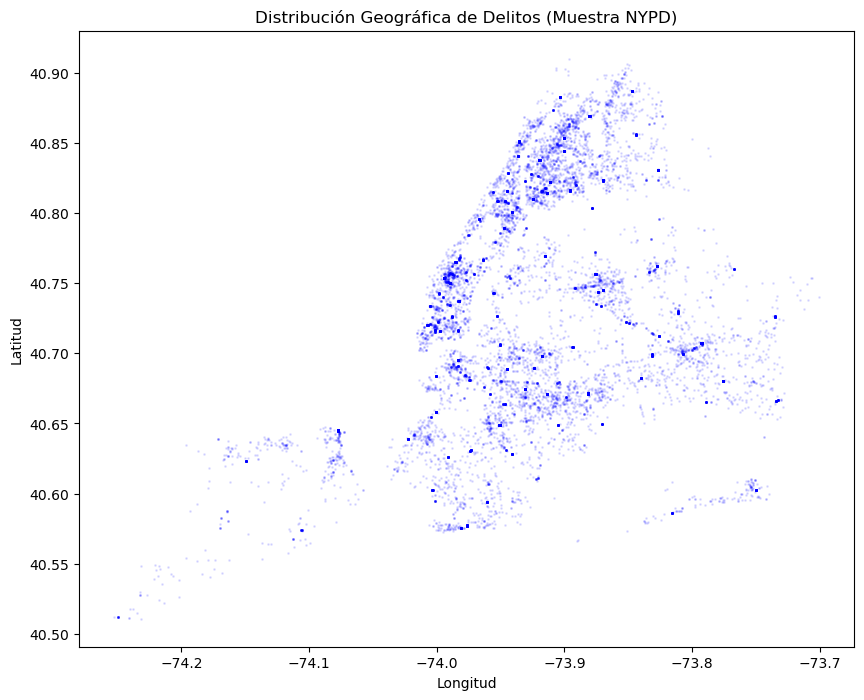

In [21]:
# Dibuja un scatter plot con:
# eje X -> Tu elección
# eje Y -> Tu elección
# tamaño pequeño de punto y cierta transparencia

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.scatter(muestra['Longitude'], muestra['Latitude'], s=1, alpha=0.1, color='blue')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Distribución Geográfica de Delitos (Muestra NYPD)')
plt.show()

## 6. Escalado

In [22]:
from sklearn.preprocessing import StandardScaler

X_data = muestra[['Latitude', 'Longitude']].dropna()


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

print(X_scaled[:5])

[[-0.69441217  1.95252867]
 [ 0.17622485 -0.89663735]
 [-1.04831578 -0.39021733]
 [-1.03191088 -1.14933717]
 [-1.59985376  2.26492796]]


## 7. Orientación para elegir eps

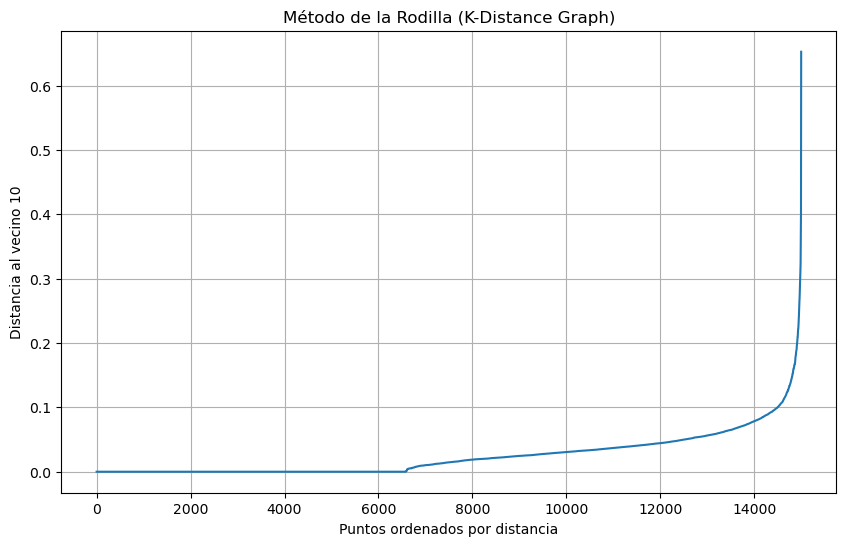

In [23]:
min_samples = 10

# Calcula los vecinos más cercanos
# vecinos = ...
# vecinos.fit(...)

# Obtén las distancias
# distancias, indices = ...

# Quédate con la distancia al vecino número min_samples
# distancias_ordenadas = ...

# Ordénalas y represéntalas



from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples = 10

vecinos = NearestNeighbors(n_neighbors=min_samples)
vecinos.fit(X_scaled)

distancias, indices = vecinos.kneighbors(X_scaled)


distancias_al_k_vecino = distancias[:, min_samples - 1]

distancias_ordenadas = np.sort(distancias_al_k_vecino)

plt.figure(figsize=(10, 6))
plt.plot(distancias_ordenadas)
plt.title('Método de la Rodilla (K-Distance Graph)')
plt.xlabel('Puntos ordenados por distancia')
plt.ylabel(f'Distancia al vecino {min_samples}')
plt.grid(True)
plt.show()

## 8. Aplicación de DBSCAN

In [24]:
# Crea el modelo DBSCAN con un eps inicial razonable (no olvides justificar)
# modelo = ...

# Entrena el modelo y obtén las etiquetas
# clusters = ...

# Añade la columna cluster a la muestra




from sklearn.cluster import DBSCAN

# 1. Crea el modelo DBSCAN
# Justificación: Elegimos eps=0.2 como valor inicial basado en la "rodilla" del gráfico anterior.
# Un eps muy pequeño (ej. 0.05) generaría demasiado ruido (puntos negros), 
# mientras que uno muy grande (ej. 0.8) uniría barrios distintos en un solo cluster.
modelo = DBSCAN(eps=0.2, min_samples=10)

clusters = modelo.fit_predict(X_scaled)

muestra['cluster'] = clusters

n_clusters_ = len(set(clusters)) - (1 if -1 in clusters else 0)
print(f"Se han detectado {n_clusters_} clusters y {list(clusters).count(-1)} puntos de ruido.")

Se han detectado 6 clusters y 32 puntos de ruido.


In [ ]:
# Calcula:
# - número de clusters (sin contar el ruido)
# - número de puntos ruido
# - tamaño de cada etiqueta

## 9. Visualización final

In [ ]:
# Representa los puntos preferentemente en distinto color según el cluster encontrado

## 10. Interpretación

Responde brevemente:

1. ¿Qué significa la etiqueta `-1`?
2. ¿Por qué DBSCAN puede detectar ruido y K-Means no?
3. ¿Qué pasa si `eps` es demasiado pequeño?
4. ¿Qué pasa si `eps` es demasiado grande?
5. ¿Por qué este dataset es más adecuado para DBSCAN que otros más simples?

## 11. Opcional

Prueba una de estas ampliaciones:
- Compara con K-Means.
- Usa una muestra más grande.
- Analiza sólo un tipo de delito.